In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

In [2]:
#Load data
df=pd.read_csv('../data/featured_data/featured_data.csv')

In [3]:
X=df.drop(columns=['Target'])
y=df['Target']

In [4]:
#Train/Test split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

In [5]:
print(f"Train:{X_train.shape}, Test:{X_test.shape}")
print(f"Target distribution:\n{y_train.value_counts(normalize=True)}")

Train:(1075212, 44), Test:(268803, 44)
Target distribution:
Target
0    0.800398
1    0.199602
Name: proportion, dtype: float64


In [9]:
#Scale features
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

In [20]:
# ============================================
# 1. LOGISTIC REGRESSION (Baseline Model)
# ============================================
print("Training Logistic Regression...")
lr_model=LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr= lr_model.predict(X_test_scaled)
y_proba_lr=lr_model.predict_proba(X_test_scaled)[:,1]

Training Logistic Regression...


In [19]:
# ============================================
# 2. RANDOM FOREST
# ============================================
print("Training Random Forest...")

rf_model= RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42,
                                 class_weight='balanced',n_jobs=-1)

rf_model.fit(X_train_scaled,y_train)

y_pred_rf=rf_model.predict(X_test_scaled)
y_proba_rf=rf_model.predict_proba(X_test_scaled)[:,1]

Training Random Forest...


In [21]:
print(f"y_test shape: {len(y_test)}")
print(f"y_proba_rf shape: {len(y_proba_rf)}")

y_test shape: 268803
y_proba_rf shape: 268803


In [ ]:
# ===============
# 3. XGBOOST 
# ==============

#Calculate scale_pos_weight for imbalanced data
scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight: {scale_pos_weight:.2f}")

print("Training XGBoost..")
xgb_model=XGBClassifier(n_estimators=100,max_depth=6, learning_rate=0.1,
                        scale_pos_weight=scale_pos_weight,
                        random_state=42,
                        n_jobs=-1,
                        eval_metric='auc')

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb= xgb_model.predict(X_test_scaled)
y_proba_xgb= xgb_model.predict_proba(X_test_scaled)[:,1]

Scale pos weight: 4.01
Training XGBoost..


In [22]:
# ============================================
# EVALUATION FUNCTION
# ============================================
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{'='*50}")
    print(f"{name} Results")
    print('='*50)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }


In [23]:
# ============================================
# COMPARE ALL MODELS
# ============================================
results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_proba_xgb))

# Create comparison DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))



Logistic Regression Results
Accuracy:  0.6598
Precision: 0.3228
Recall:    0.6419
F1 Score:  0.4296
ROC-AUC:   0.7114

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.76    215149
           1       0.32      0.64      0.43     53654

    accuracy                           0.66    268803
   macro avg       0.60      0.65      0.59    268803
weighted avg       0.77      0.66      0.69    268803


Random Forest Results
Accuracy:  0.6413
Precision: 0.3141
Recall:    0.6733
F1 Score:  0.4283
ROC-AUC:   0.7120

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215149
           1       0.31      0.67      0.43     53654

    accuracy                           0.64    268803
   macro avg       0.60      0.65      0.58    268803
weighted avg       0.77      0.64      0.68    268803


XGBoost Results
Accuracy:  0.6494
Precision: 0.3213
Recall:    0.

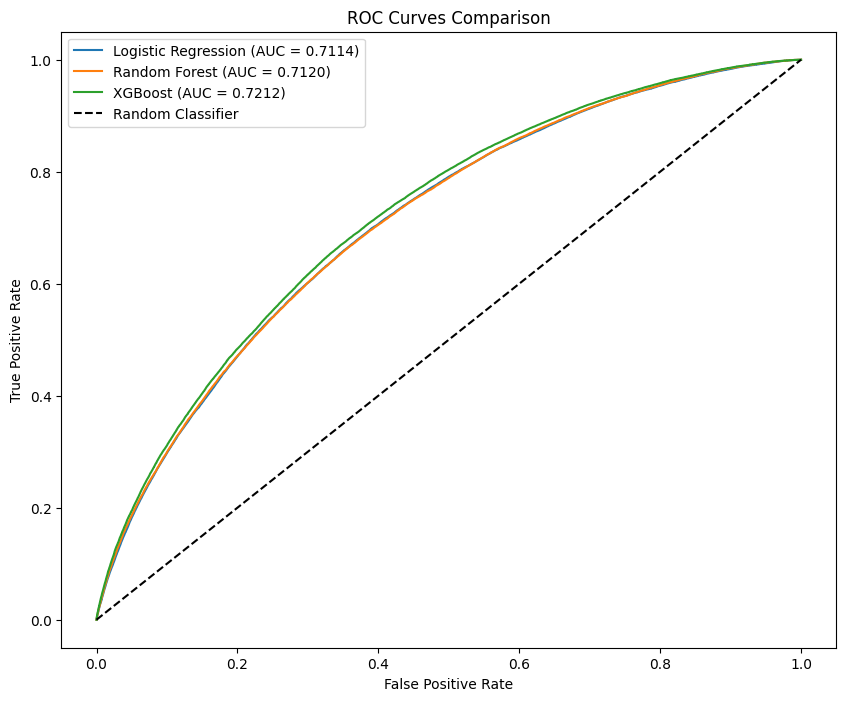

In [24]:
# ============================================
# ROC CURVES
# ============================================
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 8))

for name, y_proba in [("Logistic Regression", y_proba_lr), 
                       ("Random Forest", y_proba_rf), 
                       ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison')
ax.legend()
plt.show()


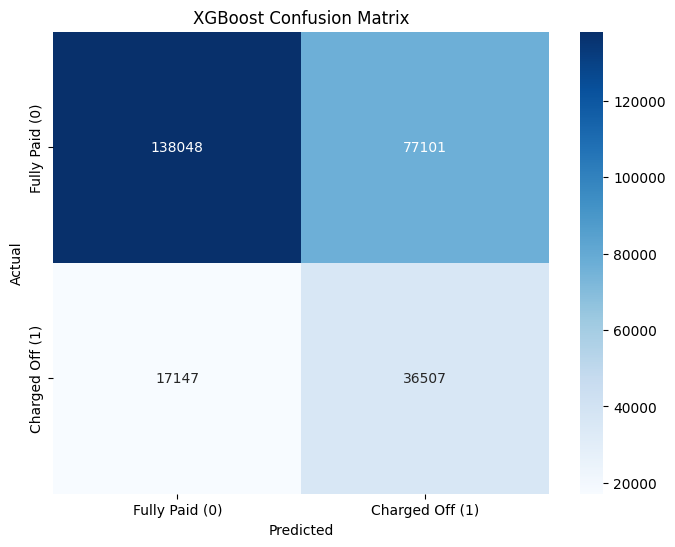

In [25]:
# ============================================
# CONFUSION MATRIX (XGBoost)
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('XGBoost Confusion Matrix')
ax.set_xticklabels(['Fully Paid (0)', 'Charged Off (1)'])
ax.set_yticklabels(['Fully Paid (0)', 'Charged Off (1)'])
plt.show()


In [26]:
# ============================================
# SAVE MODELS AND SCALER
# ============================================
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save XGBoost (best model)
with open('../models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save scaler (needed for predictions)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names = X.columns.tolist()
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Models saved successfully!")
print(f"Features: {len(feature_names)}")


Models saved successfully!
Features: 44
